# Assignment 3: Classification with Logistic Regression

## Instructions

* Complete the assignment as outlined below.
* Restart your kernel and rerun your cells before submission.
* Submit your completed notebook (.ipynb).

## Dataset Information

The dataset contains health-related data for predicting diabetes. Below are the features:

* `Pregnancies`: Number of pregnancies
* `Glucose`: Plasma glucose concentration
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skin fold thickness (mm)
* `Insulin`: 2-hour serum insulin (mu U/ml)
* `BMI`: Body mass index
* `DiabetesPedigreeFunction`: Diabetes pedigree function
* `Age`: Age (years)
* `Outcome`: Target variable (1 = Diabetes, 0 = No Diabetes)

Your goal in this homework is to train a first model for predicting the probability that a patient has diabetes given their healthcare data.

In [1]:
# Suggested packages, you can add more if you think they are necessary.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report


# Plotting packages
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Download the data. Uncomment if using Colab.
!gdown https://drive.google.com/uc?id=1-_YcEl0q5LsDXRq5eix9K4gjSq78Ffd5

Downloading...
From: https://drive.google.com/uc?id=1-_YcEl0q5LsDXRq5eix9K4gjSq78Ffd5
To: /content/diabetes.csv
100% 23.1k/23.1k [00:00<00:00, 40.5MB/s]


## Question 1:

1. Load the dataset `diabetes.csv` and display the first 5 rows.
2. Print out all columns in the dataset and identify any missing values.
3. Show the descriptive statistics of the data.

In [3]:
# Load the dataset
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Report number of null values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
# Show descriptive statistics
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
for column in df.columns:
    num_zeros = (df[column] == 0).sum()
    print(f"Number of zeros in '{column}': {num_zeros}")

Number of zeros in 'Pregnancies': 111
Number of zeros in 'Glucose': 5
Number of zeros in 'BloodPressure': 35
Number of zeros in 'SkinThickness': 227
Number of zeros in 'Insulin': 374
Number of zeros in 'BMI': 11
Number of zeros in 'DiabetesPedigreeFunction': 0
Number of zeros in 'Age': 0
Number of zeros in 'Outcome': 500


While there is no NAs directly, there are zeros elsewhere where it is clearly not meant to be there. Number of glucose, Blood Pressure, Skinthickness, BMI, Age zero is questionable

In [7]:
zeros=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zeros] = df[zeros].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Now that the zeros are null, can make it from median number.

In [8]:
df.fillna(df.median(), inplace=True)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Question 2:

What is the baseline accuracy for this classification problem? Baseline accuracy is the accuracy of always predicting the most common class. You can assume there are no outliers in the data.

In [11]:
# Question 2 code
common=df['Outcome'].value_counts().idxmax()
common

0

In [12]:
baseline=df['Outcome'].value_counts()[common]/len(df)
round(baseline*100,3)

65.104

## Question 3:

Split the data into training and testing sets. Use 70% of the data for training and 30% for testing. Pass `random_state = 42` to `train_test_split`. Ensure the `Outcome` column is the response variable. Report the descriptive statistics of X_train and X_test.

In [20]:
# Question 3 code
Xtrain,Xtest,ytrain,ytest=train_test_split(df.drop('Outcome',axis='columns'),df['Outcome'],test_size=0.3,random_state=42,stratify = df['Outcome'])



# Show the descriptive stats
Xtrain.describe()





,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000
mean,3.882682,121.564246,72.227188,28.886406,138.057728,32.615829,0.480529,33.551210
std,3.350097,29.951703,12.186692,8.259105,79.727535,6.730690,0.335253,11.794639
min,0.000000,57.000000,24.000000,7.000000,16.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,25.000000,122.000000,27.800000,0.246000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.385000,30.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.400000,0.645000,41.000000
max,17.000000,198.000000,122.000000,60.000000,744.000000,67.100000,2.329000,81.000000


In [15]:
Xtest.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000
mean,4.121212,121.000000,72.744589,29.943723,140.861472,32.870996,0.476424,33.627706
std,3.597467,31.171894,11.859674,9.453380,86.571950,6.658919,0.305519,11.949165
min,0.000000,61.000000,46.000000,7.000000,15.000000,18.400000,0.088000,21.000000
25%,1.000000,97.500000,64.000000,27.000000,123.500000,28.750000,0.245500,24.000000
50%,3.000000,115.000000,72.000000,29.000000,125.000000,32.700000,0.370000,29.000000
75%,7.000000,145.000000,78.000000,33.000000,126.000000,36.800000,0.666000,41.000000
max,13.000000,197.000000,114.000000,99.000000,680.000000,57.300000,1.600000,67.000000


**Written question: Are the descriptive statistics of the X_train and X_test datasets similar? Is this a reasonable dataset for the problem?**

**Written answer:**

## Question 4:

1. Create a pipeline that first standardizes the data using a z-scale transform, and then trains an instance of `LogisticRegression` with `penalty = None` and `max_iter = 1000`. Use the same random seed you used before.
2. Train the pipeline using the training set.

In [21]:
# Question 4 code
# Create a pipeline that scales the features and trains a logistic regression model
transform=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
transform_number=ColumnTransformer([('scaler',StandardScaler(),transform)],remainder='passthrough',verbose_feature_names_out=False)
pipe=Pipeline([('scaler',transform_number),('logistic_reg',LogisticRegression(solver='lbfgs',penalty=None,max_iter=1000,verbose=1,random_state=42,n_jobs=-1,class_weight='balanced'))])

# Train the pipeline
pipe.fit(Xtrain,ytrain)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Pipeline(steps=[('scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])],
                                   verbose_feature_names_out=False)),
                ('logistic_reg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, penalty=None, random_state=42,
                                    verbose=1))])

## Question 5:

1. Compute the model’s accuracy on the training and testing sets.
2. Display the model’s coefficients and intercept.

In [22]:
# Display coefficients
# Get the training parameters in a dataframe with the corresponding feature names
training_params = pd.DataFrame(pipe.named_steps['logistic_reg'].coef_,columns=Xtrain.columns)


# Get the intercept of the logistic regression model
training_params['intercept'] = pipe.named_steps['logistic_reg'].intercept_
training_params


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,intercept
0,0.4735,1.156636,-0.022251,-0.119962,-0.033613,0.780925,0.273168,0.132503,-0.246915


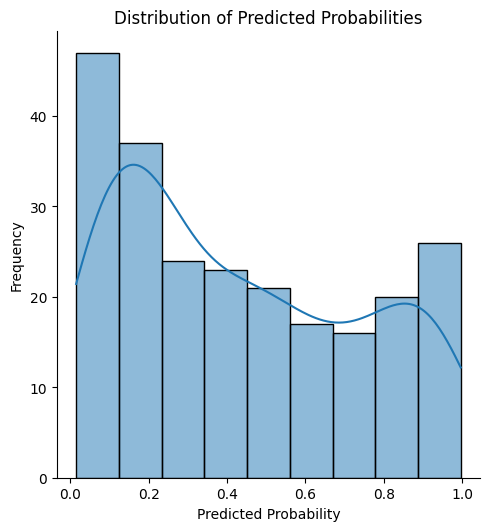

In [23]:
# Predict on test
ytest_pred = pipe.predict_proba(Xtest)

# Plot the distribution of the predicted values
sns.displot(ytest_pred[:,1], kde=True)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

In [24]:
# Calculate accuracy
print(classification_report(ytest, pipe.predict(Xtest)))




              precision    recall  f1-score   support

           0       0.84      0.79      0.82       150
           1       0.65      0.72      0.68        81

    accuracy                           0.77       231
   macro avg       0.74      0.75      0.75       231
weighted avg       0.77      0.77      0.77       231



Accuracy of 77%, higher than the baseline.

## Question 6:

1. Plot the ROC curve for the logistic regression model using the testing set. Make sure your plot includes a title and properly labeled axes.
2. Compute the area under the curve (AUC). Report the AUC at the top-left of your plot.

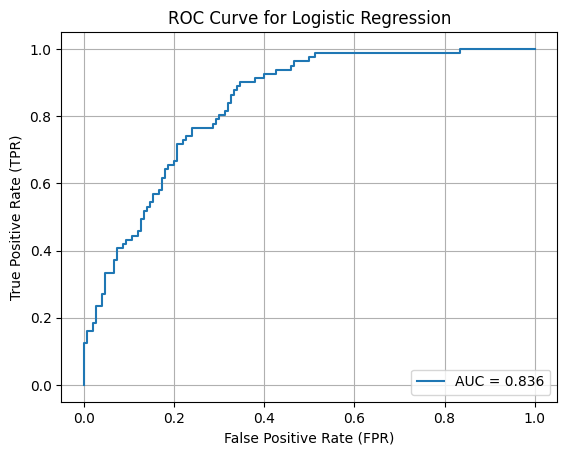

In [25]:
# Question 6 code
# Compute probabilities
fpr, tpr, thresholds = roc_curve(y_true=ytest, y_score=ytest_pred[:,1])
auc = np.round(roc_auc_score(y_true=ytest, y_score=ytest_pred[:,1]),
               decimals = 3)

# Plot ROC curve
plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Logistic Regression")
plt.legend(loc=4)
plt.grid()
plt.show()

**Written question: Comment on the capacity of the model to predict the outcome. Is the AUC acceptable?**

**Written answer:** The model seems to be doing a very good job and the AUC is acceptable. The test accuracy is higher than the baseline, the AUC of 0.836 is a good level.